# Clean QR error experiments

This notebook can either regenerate results or reload existing CSV files before plotting.

In [21]:
from pathlib import Path

import numpy as np

from error_analysis import (
    fit_error_growth,
    get_or_run_results,
    make_fit_table,
    run_qr_method_experiments,
    run_qr_precision_experiments,
    save_results,
)
from core.plotter import (
    plot_precision_comparison_for_ppt,
    plot_qr_grid,
    plot_qr_metric_for_ppt,
)

In [22]:
# Set this to True when you want to recompute experiments.
# Keep it False to reuse saved CSV results and only redraw figures.
REGENERATE_RESULTS = True

RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")
RESULTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

n_values = np.round(np.logspace(np.log10(20), np.log10(512), num=12)).astype(int)

# Parallelization here is experiment-level parallelism over independent trials.
# It is NOT a parallel QR algorithm.
PARALLEL = True
BACKEND = "threads"  # "threads", "processes", or "none"
MAX_WORKERS = 4

## 1. Method comparison
Householder vs WY vs Block QR under float32/float64.

In [23]:
method_csv = RESULTS_DIR / "qr_method_comparison.csv"

df_methods = get_or_run_results(
    method_csv,
    runner=lambda: run_qr_method_experiments(
        n_values=n_values,
        methods=("Householder", "WY", "Block QR"),
        precisions=(np.float32, np.float64),
        repeats=20,
        block_size=32,
        seed=42,
        data_type="uniform",
        parallel=PARALLEL,
        backend=BACKEND,
        max_workers=MAX_WORKERS,
        show_progress=True,
    ),
    regenerate=REGENERATE_RESULTS,
)

# Optional JSON copy
save_results(df_methods, RESULTS_DIR / "qr_method_comparison.json")

df_methods.head()

Generating new results and saving to: results\qr_method_comparison.csv
Completed 144/1440 tasks
Completed 288/1440 tasks
Completed 432/1440 tasks
Completed 576/1440 tasks
Completed 720/1440 tasks
Completed 864/1440 tasks
Completed 1008/1440 tasks
Completed 1152/1440 tasks
Completed 1296/1440 tasks
Completed 1440/1440 tasks


,n,m,trial,method,precision,reconstruction,orthogonality,least_squares
0,20,40,0,Block QR,float32,1.323160e-07,2.211391e-07,0.127318
1,20,40,0,Block QR,float64,4.014826e-16,4.753238e-16,0.130568
2,20,40,0,Householder,float32,1.951293e-07,2.420668e-07,0.129381
3,20,40,0,Householder,float64,2.691003e-16,4.352662e-16,0.143856
4,20,40,0,WY,float32,6.949935e-08,1.971416e-07,0.102537


In [24]:
fit_methods = fit_error_growth(df_methods, group_columns=("method", "precision"))
make_fit_table(fit_methods)

method precision statistic             c                \
metric                                  Least Squares Orthogonality   
0          Block QR   float32       max        -1.633       -17.031   
1          Block QR   float64       max        -1.623       -36.461   
2       Householder   float32       max        -1.608       -16.330   
3       Householder   float64       max        -1.659       -36.250   
4                WY   float32       max        -1.605       -16.020   
5                WY   float64       max        -1.661       -35.927   

                                  k                               \
metric Reconstruction Least Squares Orthogonality Reconstruction   
0             -15.541        -0.057         0.559          0.123   
1             -36.069        -0.059         0.410          0.274   
2             -15.492        -0.059         0.374          0.074   
3             -35.647        -0.053         0.371          0.196   
4             -15.863        -0.063         0.251          0.140   
5             -35.993        -0.052         0.254          0.265   

           r_squared                               
metric Least Squares Orthogonality Reconstruction  
0              0.846         0.940          0.653  
1              0.845         0.970          0.917  
2              0.872         0.978          0.252  
3              0.802         0.990          0.781  
4              0.719         0.960          0.405  
5              0.882         0.980          0.743

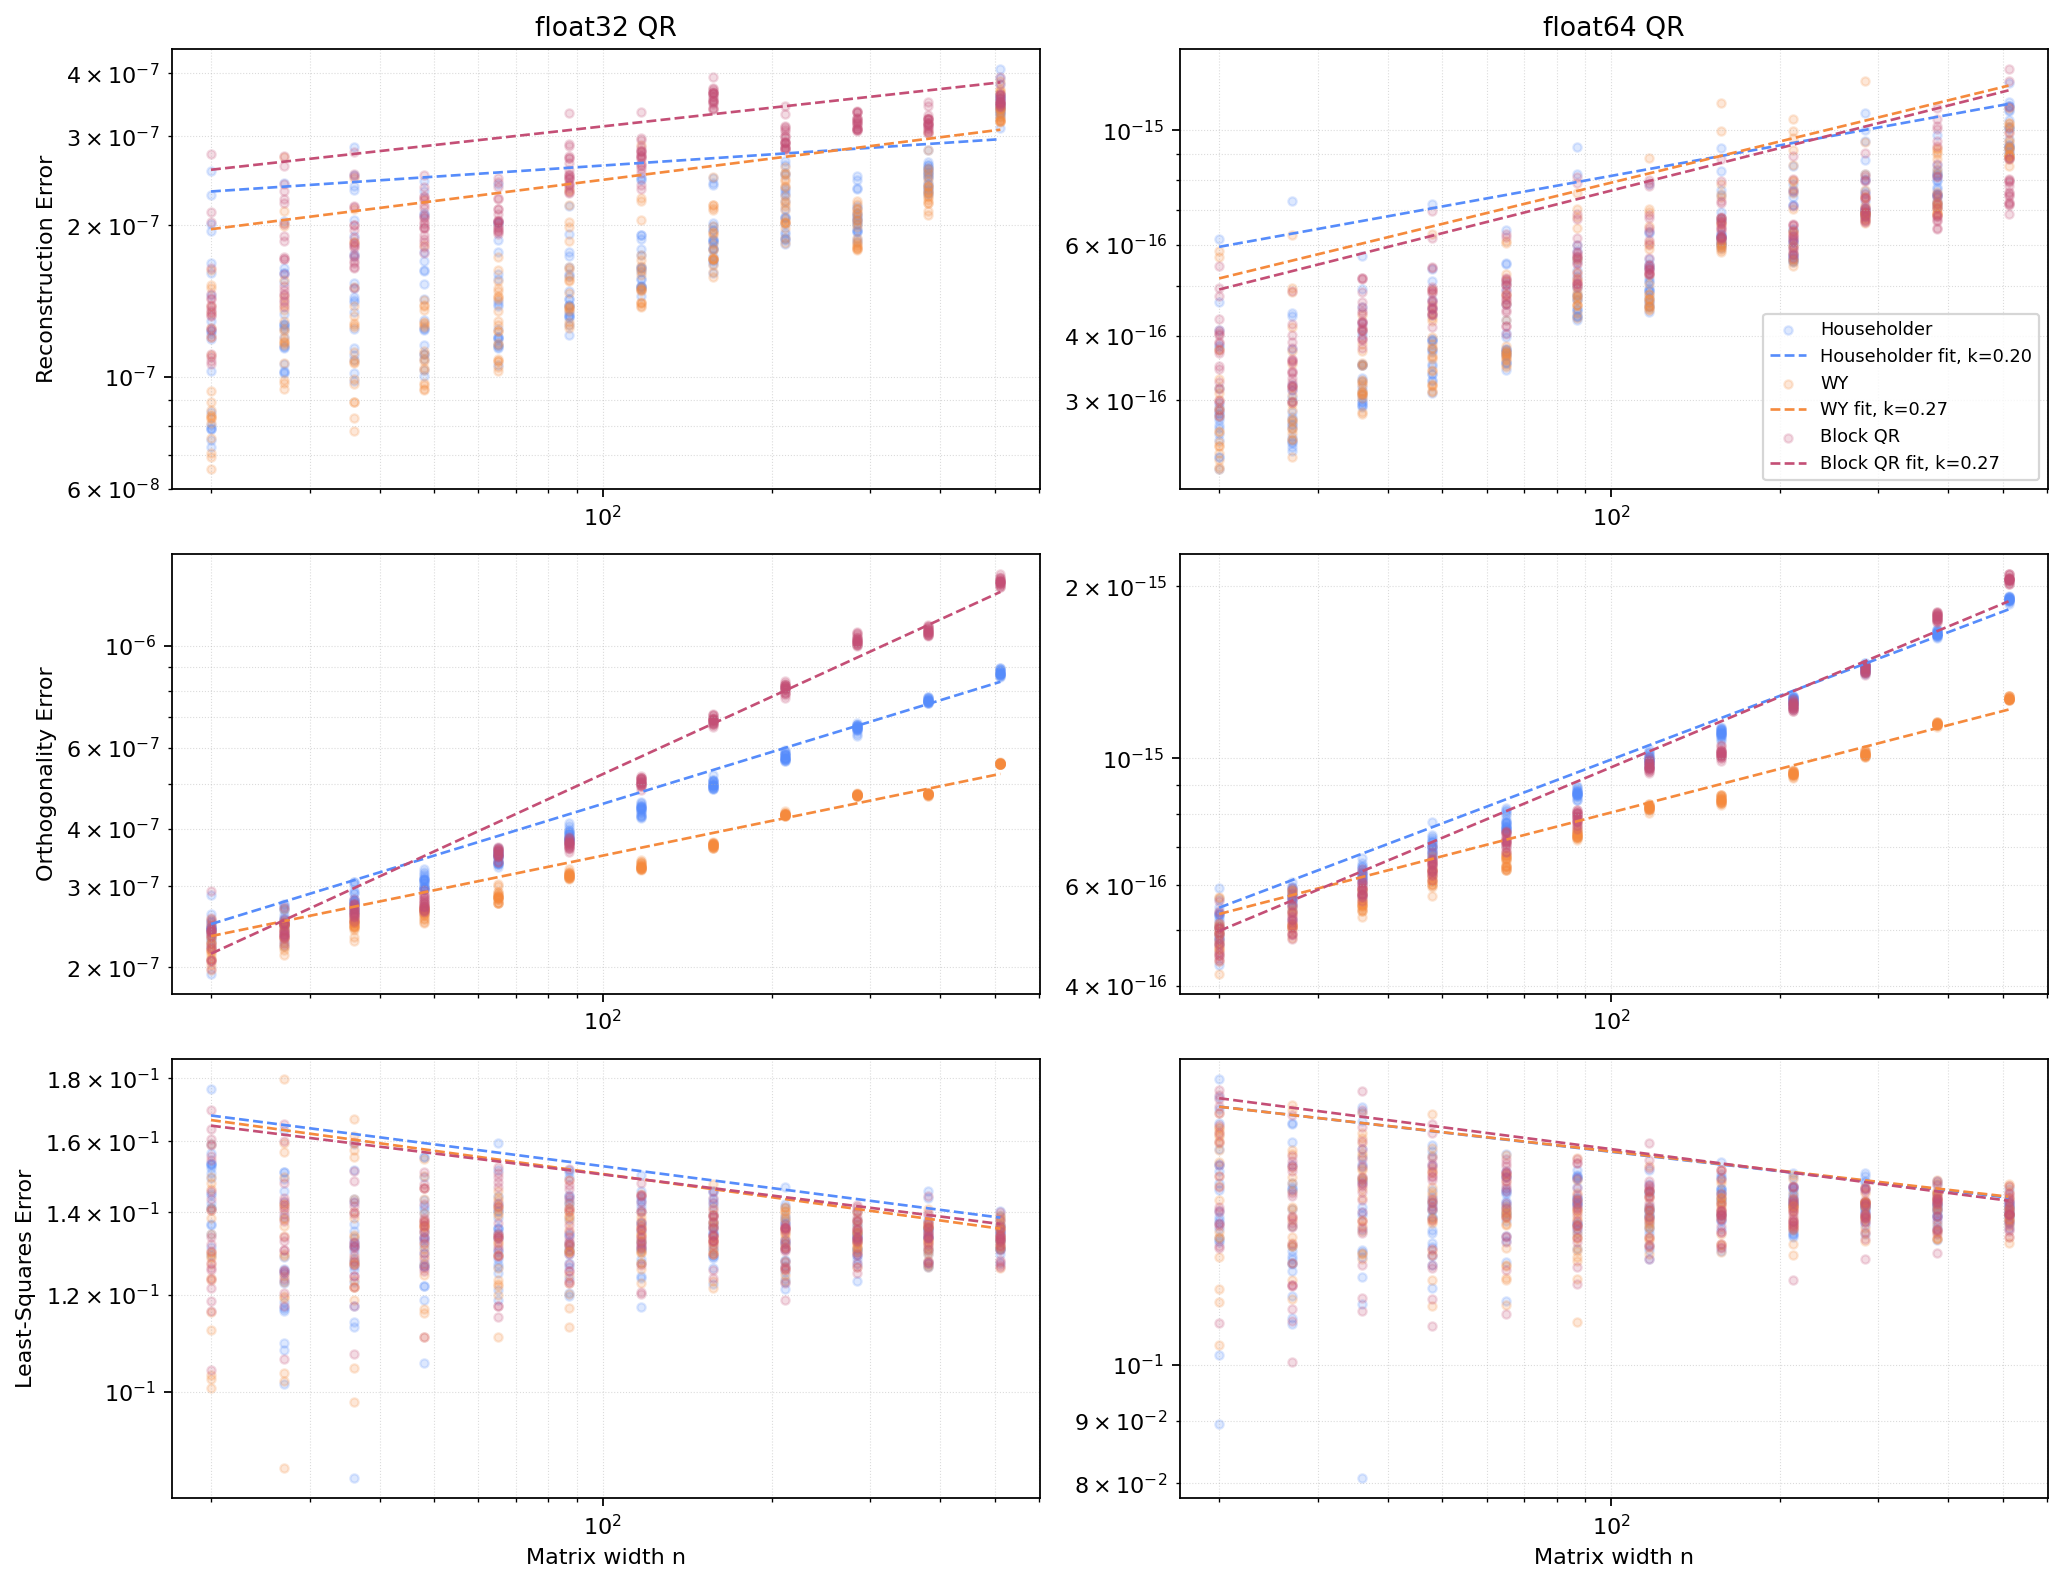

In [25]:
plot_qr_grid(
    df_methods,
    save_path=FIGURES_DIR / "qr_error_grid.png",
    show_fit=True,
)

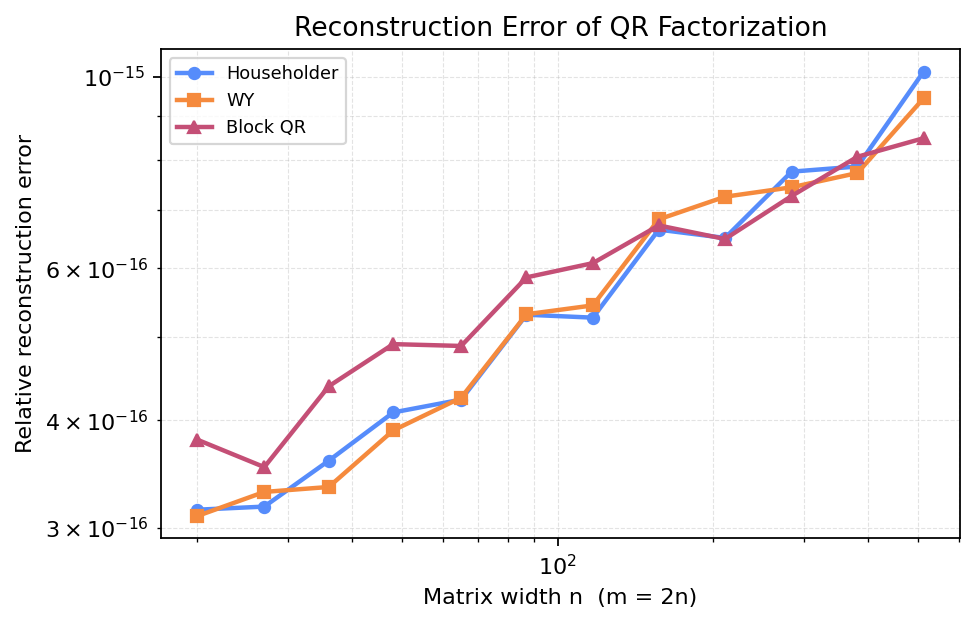

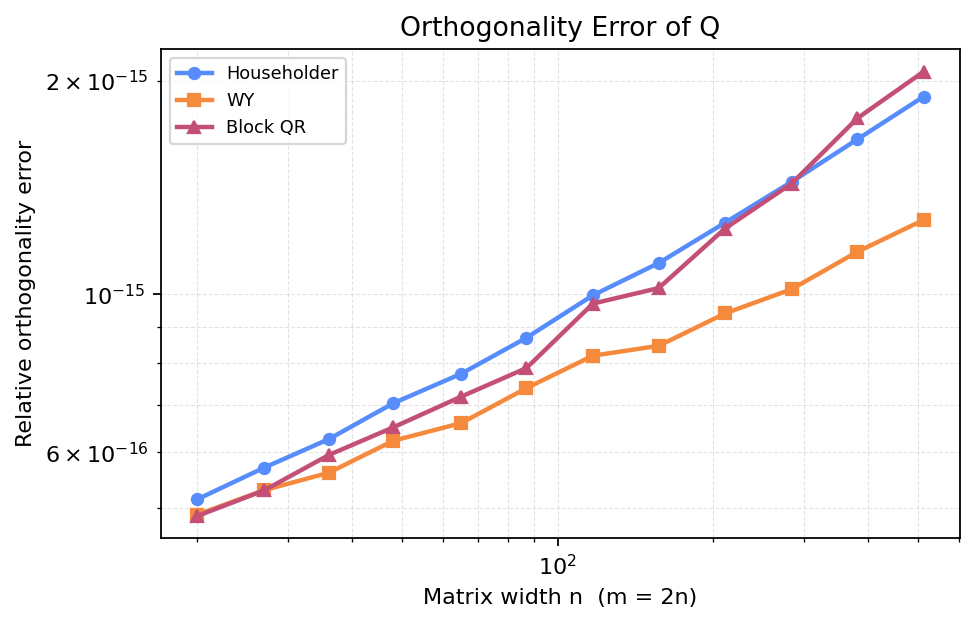

In [26]:
plot_qr_metric_for_ppt(
    df_methods,
    metric="reconstruction",
    precision="float64",
    title="Reconstruction Error of QR Factorization",
    ylabel="Relative reconstruction error",
    save_path=FIGURES_DIR / "qr_reconstruction_float64_ppt.png",
)

plot_qr_metric_for_ppt(
    df_methods,
    metric="orthogonality",
    precision="float64",
    title="Orthogonality Error of Q",
    ylabel="Relative orthogonality error",
    save_path=FIGURES_DIR / "qr_orthogonality_float64_ppt.png",
)

## 2. Precision comparison
Float64 vs Float32 vs simulated mixed-FMA QR.

Note: `mixed_fma32_64` is currently implemented for Householder QR only. It simulates FP32 storage between Householder steps with FP64 local product/add accumulation.

In [27]:
precision_csv = RESULTS_DIR / "qr_mixed_fma_precision_comparison.csv"

# mixed_fma32_64 is Householder-only.
df_precision = get_or_run_results(
    precision_csv,
    runner=lambda: run_qr_precision_experiments(
        n_values=n_values,
        methods=("Householder",),
        precision_modes=("float64", "float32", "mixed_fma32_64"),
        repeats=20,
        block_size=32,
        seed=42,
        data_type="uniform",
        reference="working",
        parallel=PARALLEL,
        backend=BACKEND,
        max_workers=MAX_WORKERS,
        show_progress=True,
    ),
    regenerate=REGENERATE_RESULTS,
)

# Optional JSON copy
save_results(df_precision, RESULTS_DIR / "qr_mixed_fma_precision_comparison.json")

df_precision.head()

Generating new results and saving to: results\qr_mixed_fma_precision_comparison.csv
Completed 72/720 tasks
Completed 144/720 tasks
Completed 216/720 tasks
Completed 288/720 tasks
Completed 360/720 tasks
Completed 432/720 tasks
Completed 504/720 tasks
Completed 576/720 tasks
Completed 648/720 tasks
Completed 720/720 tasks


,n,m,trial,method,precision_mode,precision_label,reference,reconstruction,orthogonality,least_squares
0,20,40,0,Householder,float32,Float32,working,6.899772e-08,2.371615e-07,0.102537
1,20,40,0,Householder,float64,Float64,working,2.538156e-16,4.732046e-16,0.129381
2,20,40,0,Householder,mixed_fma32_64,"Mixed-FMA, FP64 acc.",working,2.332026e-16,4.708544e-16,0.127318
3,20,40,1,Householder,float32,Float32,working,1.480066e-07,2.302361e-07,0.160741
4,20,40,1,Householder,float64,Float64,working,2.691003e-16,4.352662e-16,0.143856


In [28]:
fit_precision = fit_error_growth(
    df_precision,
    group_columns=("method", "precision_mode", "reference"),
)
make_fit_table(fit_precision)

method  precision_mode reference statistic             c  \
metric                                                  Least Squares   
0       Householder         float32   working       max        -1.700   
1       Householder         float64   working       max        -1.731   
2       Householder  mixed_fma32_64   working       max        -1.671   

                                                k                \
metric Orthogonality Reconstruction Least Squares Orthogonality   
0            -16.356        -15.920        -0.042         0.379   
1            -36.283        -35.946        -0.040         0.379   
2            -36.179        -36.884        -0.049         0.358   

                          r_squared                               
metric Reconstruction Least Squares Orthogonality Reconstruction  
0               0.157         0.733         0.978          0.543  
1               0.249         0.850         0.991          0.823  
2               0.505         0.839         0.980          0.863

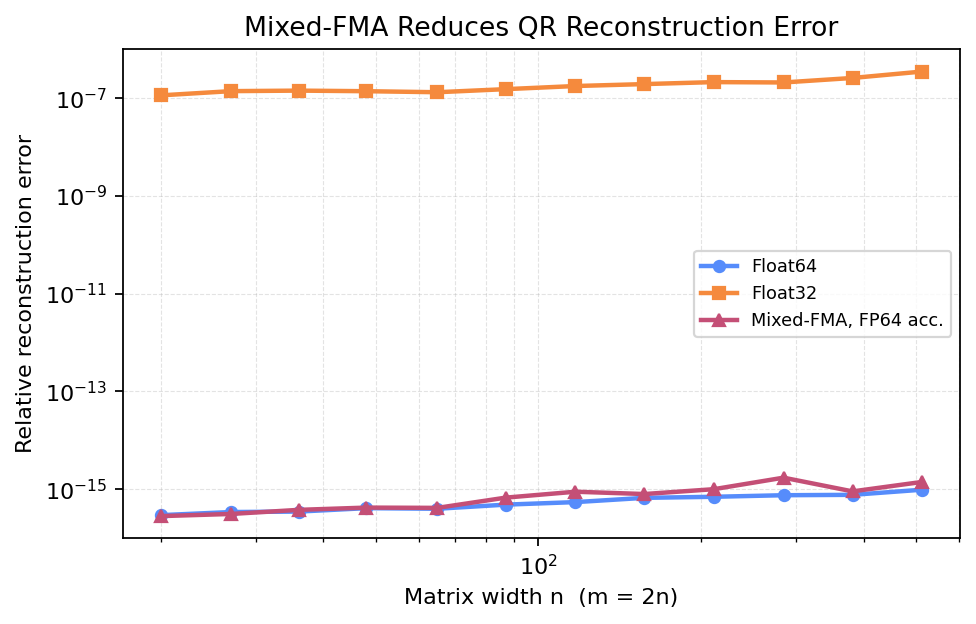

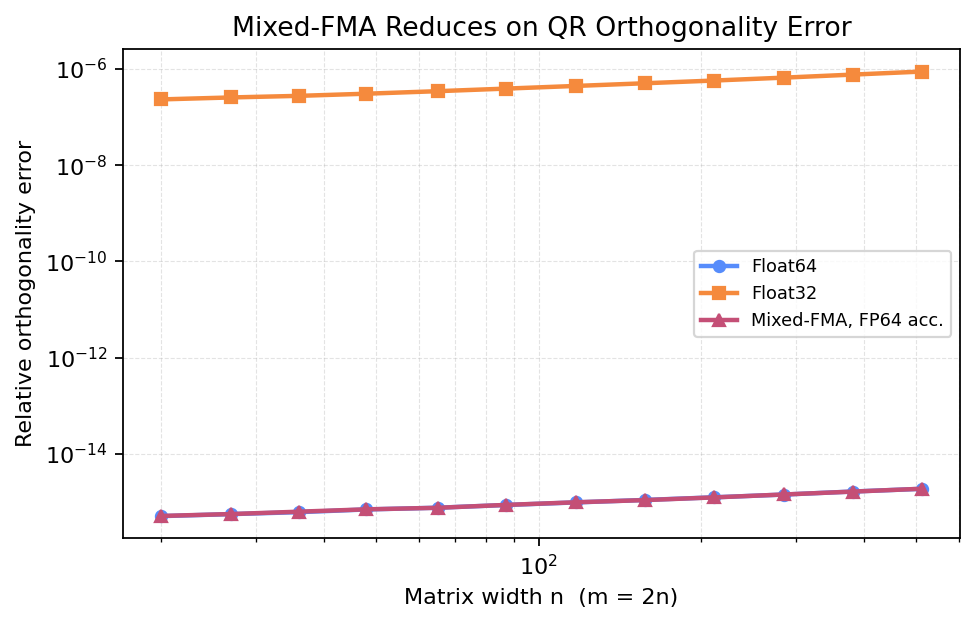

In [29]:
plot_precision_comparison_for_ppt(
    df_precision,
    method="Householder",
    metric="reconstruction",
    title="Mixed-FMA Reduces QR Reconstruction Error",
    ylabel="Relative reconstruction error",
    save_path=FIGURES_DIR / "mixed_fma_reconstruction_householder.png",
    precision_order=("float64", "float32", "mixed_fma32_64"),
)

plot_precision_comparison_for_ppt(
    df_precision,
    method="Householder",
    metric="orthogonality",
    title="Mixed-FMA Reduces on QR Orthogonality Error",
    ylabel="Relative orthogonality error",
    save_path=FIGURES_DIR / "mixed_fma_orthogonality_householder.png",
    precision_order=("float64", "float32", "mixed_fma32_64"),
)

## 3. Optional baseline: FP32 input + FP64 whole-QR computation

This is **not** the mixed-FMA QR model. It is only a reference baseline where the matrix is rounded to FP32 first and then the entire QR factorization is performed in FP64.

In [30]:
baseline_csv = RESULTS_DIR / "qr_fp32_input_fp64_qr_baseline.csv"

df_baseline = get_or_run_results(
    baseline_csv,
    runner=lambda: run_qr_precision_experiments(
        n_values=n_values,
        methods=("Householder",),
        precision_modes=("float64", "float32", "mixed32_64"),
        repeats=20,
        block_size=32,
        seed=43,
        data_type="uniform",
        reference="working",
        parallel=PARALLEL,
        backend=BACKEND,
        max_workers=MAX_WORKERS,
        show_progress=True,
    ),
    regenerate=REGENERATE_RESULTS,
)

save_results(df_baseline, RESULTS_DIR / "qr_fp32_input_fp64_qr_baseline.json")

df_baseline.head()

Generating new results and saving to: results\qr_fp32_input_fp64_qr_baseline.csv
Completed 72/720 tasks
Completed 144/720 tasks
Completed 216/720 tasks
Completed 288/720 tasks
Completed 360/720 tasks
Completed 432/720 tasks
Completed 504/720 tasks
Completed 576/720 tasks
Completed 648/720 tasks
Completed 720/720 tasks


,n,m,trial,method,precision_mode,precision_label,reference,reconstruction,orthogonality,least_squares
0,20,40,0,Householder,float32,Float32,working,7.699259e-08,2.620584e-07,0.140998
1,20,40,0,Householder,float64,Float64,working,3.332656e-16,5.290589e-16,0.143869
2,20,40,0,Householder,mixed32_64,FP32 input + FP64 QR,working,2.066288e-16,5.857577e-16,0.118745
3,20,40,1,Householder,float32,Float32,working,1.198903e-07,2.096725e-07,0.113486
4,20,40,1,Householder,float64,Float64,working,4.288382e-16,5.578407e-16,0.109161
